In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
import beorn
import tools21cm as t2c
import h5py

In [31]:
SCRATCH_ROOT = Path("/xdisk/timeifler/yhhuang/BEoRN-v2/")
FILE_ROOT = Path("/xdisk/timeifler/yhhuang/Thesan/")
CACHE_ROOT = SCRATCH_ROOT / "thesan_run_fstar" / "cache"
OUTPUT_ROOT = SCRATCH_ROOT / "thesan_run_fstar" / "output"
PARAMETER_FILE = Path("coarse_grid.yaml")

In [5]:
parameters = beorn.structs.Parameters.from_yaml(PARAMETER_FILE)
parameters.simulation.file_root = FILE_ROOT
parameters.solver.redshifts = np.sort(parameters.solver.redshifts)

output_handler = beorn.io.Handler(
    file_root=Path('/xdisk/timeifler/yhhuang/BEoRN-v2/thesan_run_fstar/output')
)

cube = output_handler.load_file(parameters, beorn.structs.TemporalCube)

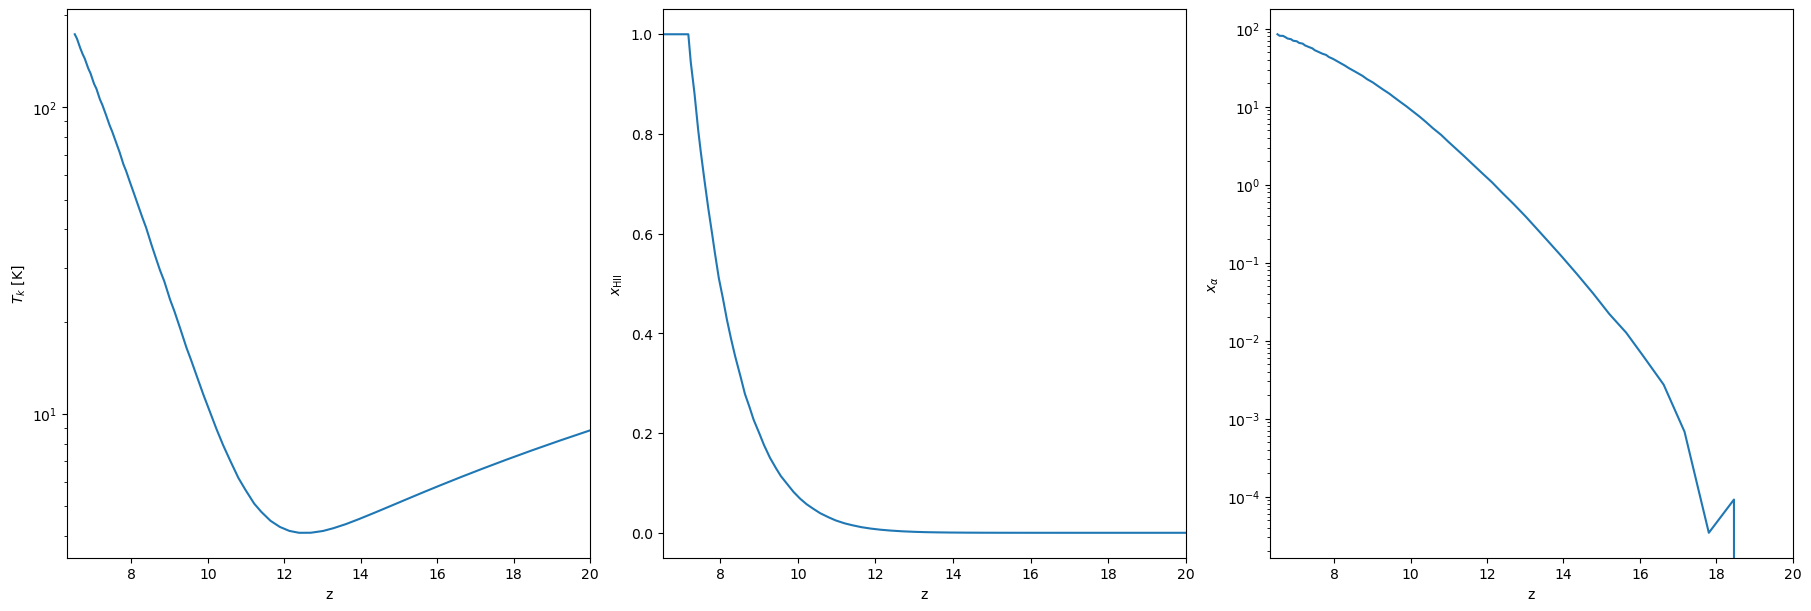

In [37]:
fig = plt.figure(constrained_layout=True)
fig.set_figwidth(18)
fig.set_figheight(6)
gs = gridspec.GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# These work if the fields exist in the TemporalCube
beorn.plotting.draw_Temp_signal(ax1, cube)
beorn.plotting.draw_x_alpha_signal(ax3, cube)

manifest_path = beorn.structs.TemporalCube.get_file_path(OUTPUT_ROOT, parameters)
snapshot_dir = beorn.structs.TemporalCube.snapshot_directory(manifest_path)

z = np.asarray(cube.z)
xHII = np.empty(z.size, dtype=float)
for snapshot_index in range(z.size):
    snapshot_path = snapshot_dir / beorn.structs.TemporalCube.snapshot_file_name(
        parameters, 'Grid_xHII', snapshot_index)
    temp = 0
    with h5py.File(snapshot_path, 'r') as f:
        dataset = f['Grid_xHII'][...]
        if dataset.shape == (1,):
            temp = float(dataset[0])
        else:
            temp = np.mean(dataset)
    xHII[snapshot_index] = temp
ax2.plot(z, xHII)
ax2.set_xlim(z.min(), z.max())
ax2.set_ylabel(r'$x_\mathrm{HII}$')
ax2.set_xlabel('z')
plt.show()

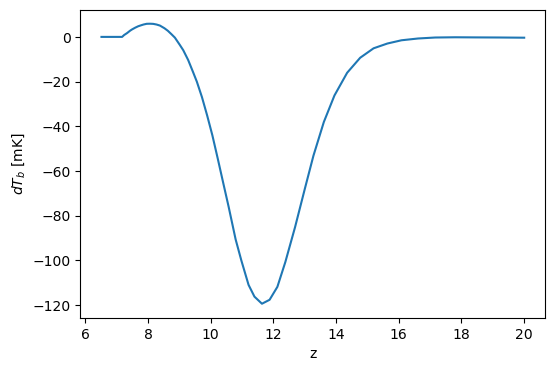

In [39]:
simulation_name = beorn.structs.TemporalCube.simulation_name(parameters)
ncell = int(parameters.simulation.Ncell)

DTB_ROOT = Path('/xdisk/timeifler/yhhuang/BEoRN-v2/thesan_run_fstar/output_dtb/')
dtb_mean = np.empty(len(z), dtype=float)

for i in range(len(z)):
    path = DTB_ROOT / f'{simulation_name}_snapshot_{i:03d}_z{float(z[i]):.6f}_Grid_dTb_N{ncell}.h5'
    with h5py.File(path, "r") as f:
        data = f["Grid_dTb"][...]
    dtb_mean[i] = float(data[0]) if data.shape == (1,) else np.mean(data)
    
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z, dtb_mean)
ax.set_xlabel("z")
ax.set_ylabel(r"$dT_b$ [mK]")
plt.show()